# SIR model fits to the first wave

Fit SIR models to the spring 2020 first wave in the US, Italy and Spain, and project them forward.

Reported case counts in early 2020 mostly measured testing capacity, so the fits use **deaths** instead:
each death stands for `a` infections that started `shift` days earlier (`CurrentCasesFromDeaths`). Two models:

- **SIR**: constant contact rate β and recovery rate γ
- **SIR4**: a fourth equation, dβ/dt = −αβI, lets the contact rate fall as infections rise (distancing,
  lockdowns)

While almost everyone is still susceptible, cumulative cases only determine the growth rate β − γ, so γ is fixed
at 1/10 per day (a 10-day infectious period) and the fits find β (or β₀ and α) and the initial infections.

Populations are in thousands of people. Data is cut at `AS_OF`, early in the first wave.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # project root, so covid19 imports without installing
from covid19.data import get_state_df, us_states_daily, world_daily
from covid19.models import (SIR, SIR4, CurrentCasesFromDeaths, CurrentCasesUndercount, ModelProjectionExponential,
                            describe_sir)

AS_OF = "2020-05-01"
PROJECTION_DAYS = 160

df, _ = us_states_daily(as_of=AS_OF)
dfw, _ = world_daily(as_of=AS_OF)
dfus = get_state_df(df, "*")

## Three estimates of total US cases

Reported positives; positives scaled up by 1.8 for missed cases; and cases inferred from deaths (250 cases per
death, infected 14 days before dying).

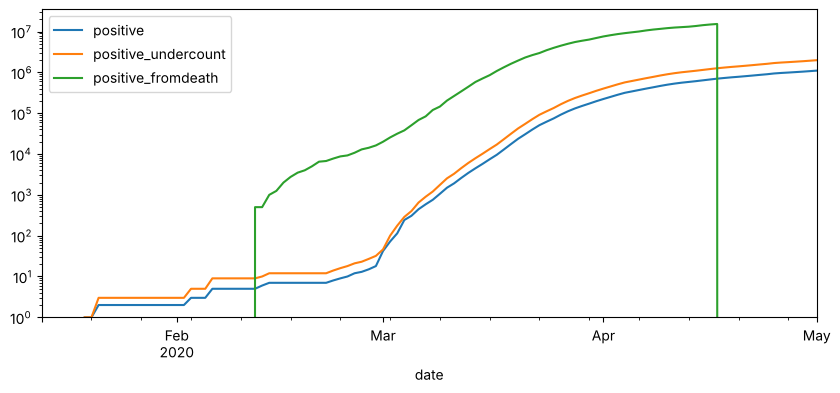

In [2]:
dfus = CurrentCasesUndercount().add_positive_estimate(dfus)
dfus = CurrentCasesFromDeaths().add_positive_estimate(dfus, params={"a": 250, "shift": 14})
ax = dfus.plot(x="date", y=["positive", "positive_undercount", "positive_fromdeath"], figsize=[10, 4], logy=True)
ax.set_ylim(bottom=1)
plt.show()

## Exponential projection

Extend the exponential fit of the last 10 days of reported cases 10 days ahead, with naive hospital and ICU
loads (15% and 4% of the cases from the previous 10 days).

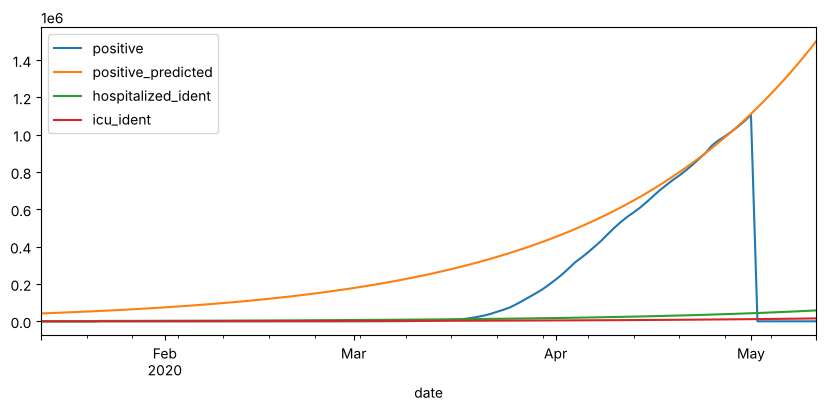

,day_number,date,positive_predicted,positive,new_daily_positive,hospitalized_ident,icu_ident
109,109,2020-05-01,1112001,1106124.0,32853.0,43218,11524
110,110,2020-05-02,1145854,0.0,33853.0,44533,11875
111,111,2020-05-03,1180738,0.0,34884.0,45889,12237
112,112,2020-05-04,1216684,0.0,35946.0,47286,12609
113,113,2020-05-05,1253724,0.0,37040.0,48726,12993
114,114,2020-05-06,1291891,0.0,38167.0,50209,13389
115,115,2020-05-07,1331221,0.0,39330.0,51738,13796
116,116,2020-05-08,1371748,0.0,40527.0,53313,14216
117,117,2020-05-09,1413508,0.0,41760.0,54936,14649
118,118,2020-05-10,1456540,0.0,43032.0,56608,15095


In [3]:
proj = ModelProjectionExponential().project(dfus, 10)
proj.plot(x="date", y=["positive", "positive_predicted", "hospitalized_ident", "icu_ident"], figsize=[10, 4])
plt.show()
proj.tail(11)

## SIR fits

`fit_and_project` builds the death-inferred case series (in thousands), drops the days before the first death,
fits the model, and plots the projection against the series it was fit to.

In [4]:
def fit_and_project(model, dfq, N, title, cases_per_death=250, shift=14, gamma=0.1):
    ccd = CurrentCasesFromDeaths()
    ccd.add_positive_estimate(dfq.copy(), params={"a": cases_per_death, "shift": shift})
    first = np.argmax(ccd.fit_series > 0)
    c = ccd.fit_series[first:] / 1000
    start_date = dfq.date.iloc[first] - pd.Timedelta(days=shift)

    fit = model.SIRFitter(c, N, gamma=gamma)
    proj = model.project(c, PROJECTION_DAYS, params={"SIR": fit, "start_date": start_date})
    if isinstance(model, SIR4):
        N, I0, R0, beta0, alpha, gamma = fit
        print(f"{title} SIR4: beta falls from {beta0:.3f} to {proj.beta.iloc[len(c) - 1]:.3f} over the fit "
              f"(alpha = {alpha:.2e})")
        print("  at the start:", describe_sir(beta0, gamma, I0))
    else:
        N, I0, R0, beta, gamma = fit
        print(f"{title} SIR:", describe_sir(beta, gamma, I0))
    print(f"  day 0 = {start_date:%Y-%m-%d}; fit to {len(c)} days")

    proj["positive"] = proj["positive"].where(proj.index < len(c))
    proj.plot(x="date", y=["positive", "positive_predicted", "infected", "removed", "hospitalized_ident", "icu_ident"],
              figsize=[12, 5], ylim=[0, 2 * c.max()], style=["k.", "-", "-", "-", "--", "--"],
              title=f"{title}: {type(model).__name__} (thousands of people)")
    plt.show()
    return proj

### United States (N = 330 million)

US SIR: R0 = beta/gamma = 2.68; early doubling time ln2/(beta-gamma) = 4.1 days; mean infectious period 1/gamma = 10.0 days; initial infections ~ 989
  day 0 = 2020-02-12; fit to 66 days


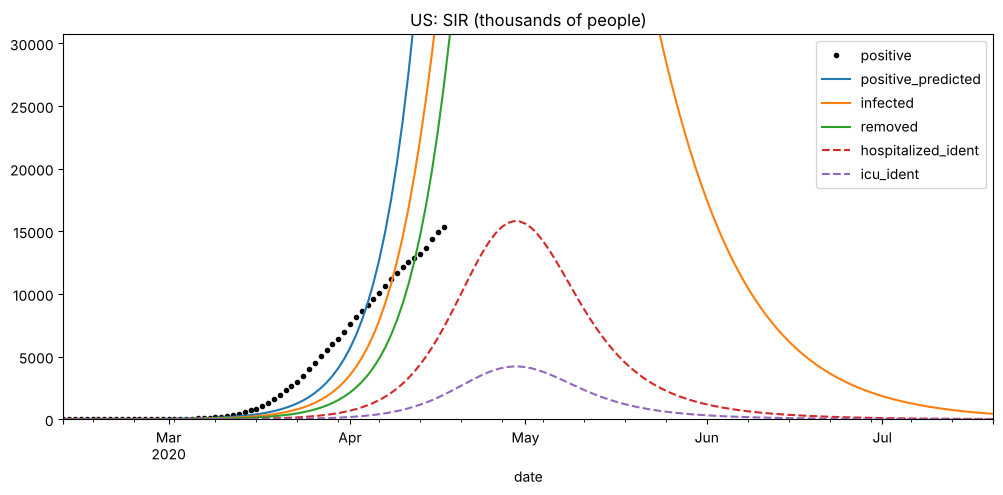

US SIR4: beta falls from 0.311 to 0.040 over the fit (alpha = 1.93e-05)
  at the start: R0 = beta/gamma = 3.11; early doubling time ln2/(beta-gamma) = 3.3 days; mean infectious period 1/gamma = 10.0 days; initial infections ~ 490
  day 0 = 2020-02-12; fit to 66 days


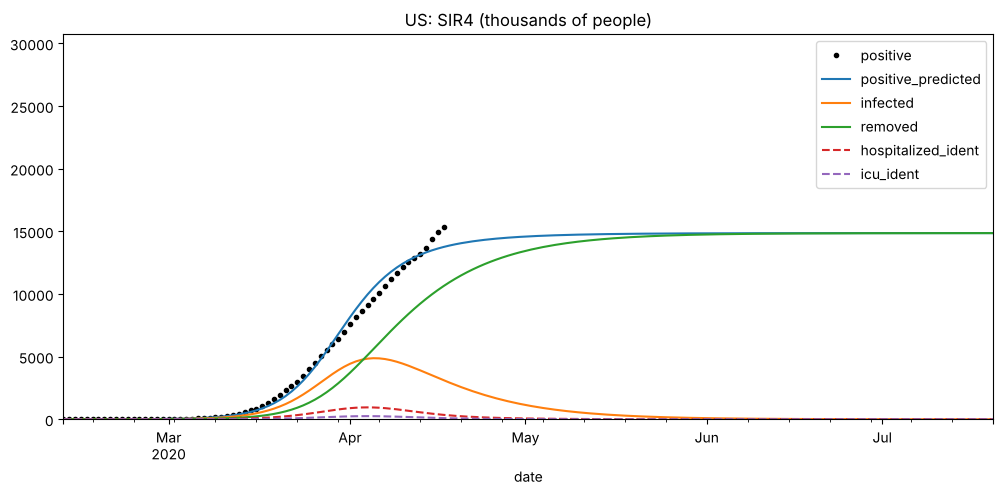

In [5]:
fits = {}
fit_and_project(SIR(), dfus, N=330_000, title="US")
fits["US"] = fit_and_project(SIR4(), dfus, N=330_000, title="US")

### Italy (N = 60 million) and Spain (N = 47 million)

200 cases per death, infected 10 days before dying.

Italy SIR: R0 = beta/gamma = 2.35; early doubling time ln2/(beta-gamma) = 5.1 days; mean infectious period 1/gamma = 10.0 days; initial infections ~ 3.24e+03
  day 0 = 2020-02-11; fit to 71 days


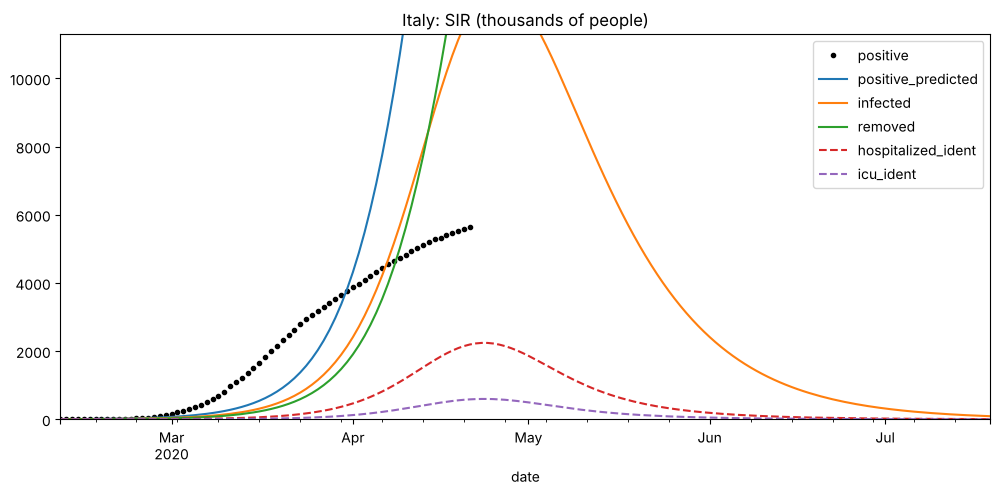

Italy SIR4: beta falls from 0.373 to 0.013 over the fit (alpha = 8.42e-05)
  at the start: R0 = beta/gamma = 3.73; early doubling time ln2/(beta-gamma) = 2.5 days; mean infectious period 1/gamma = 10.0 days; initial infections ~ 482
  day 0 = 2020-02-11; fit to 71 days


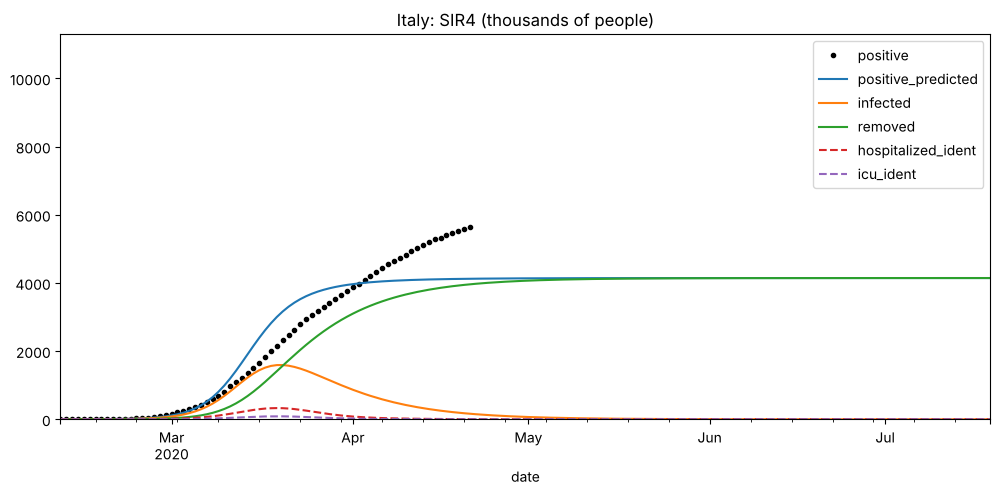

Spain SIR: R0 = beta/gamma = 2.63; early doubling time ln2/(beta-gamma) = 4.3 days; mean infectious period 1/gamma = 10.0 days; initial infections ~ 3.4e+03
  day 0 = 2020-02-22; fit to 60 days


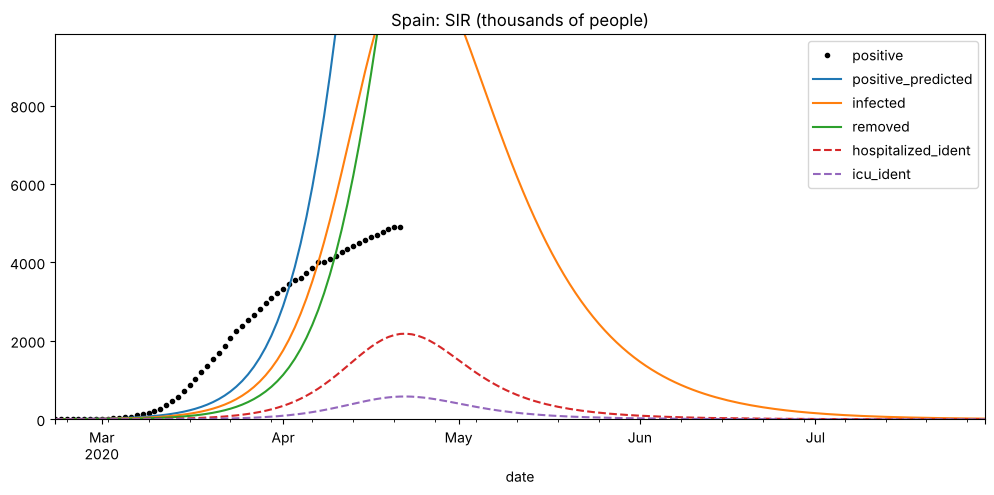

Spain SIR4: beta falls from 0.449 to 0.008 over the fit (alpha = 1.15e-04)


  at the start: R0 = beta/gamma = 4.49; early doubling time ln2/(beta-gamma) = 2.0 days; mean infectious period 1/gamma = 10.0 days; initial infections ~ 414
  day 0 = 2020-02-22; fit to 60 days


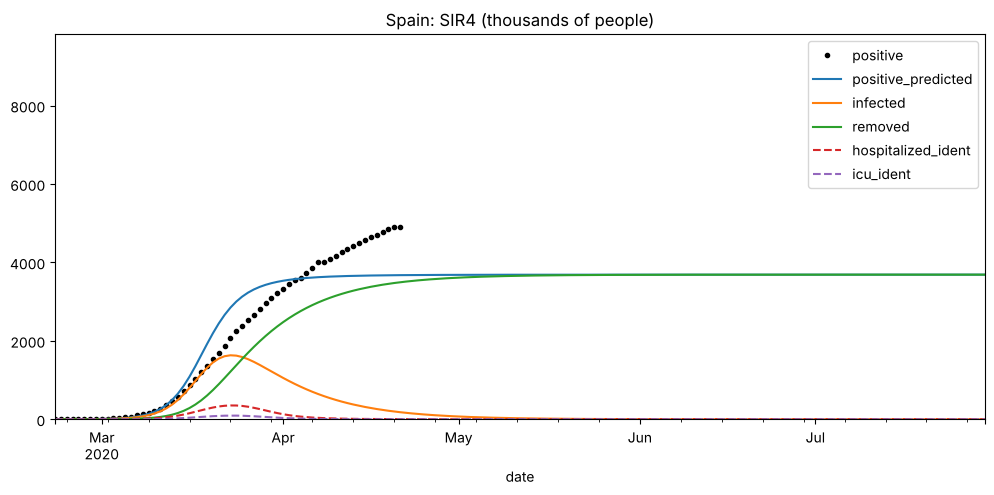

In [6]:
for country, N in [("Italy", 60_000), ("Spain", 47_000)]:
    dfq = get_state_df(dfw, country)
    fit_and_project(SIR(), dfq, N, country, cases_per_death=200, shift=10)
    fits[country] = fit_and_project(SIR4(), dfq, N, country, cases_per_death=200, shift=10)

## How the contact rate fell

The SIR4 fits' β(t). Constant-β SIR fits overshoot the data within weeks; letting β fall captures the bend in
the curves, and the fitted R(t) = β(t)/γ drops below 1 as lockdowns took hold (Italy locked down on March 9,
Spain on March 14). The US curve did not flatten like Europe's: by late April its data runs above the SIR4
fit, whose plateau comes too early.

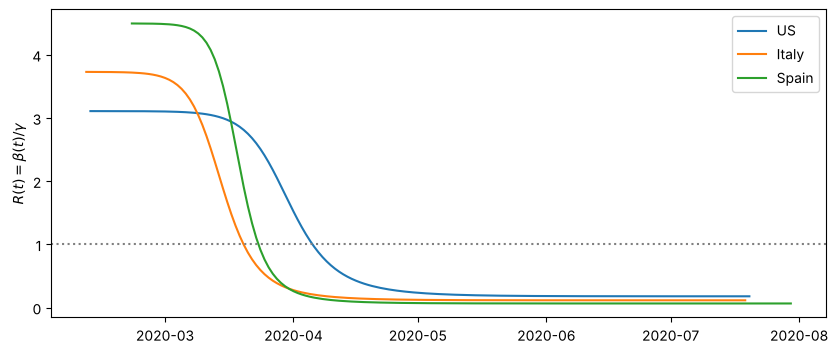

In [7]:
fig, ax = plt.subplots(figsize=[10, 4])
for place, proj in fits.items():
    ax.plot(proj.date, proj.beta / 0.1, label=place)
ax.axhline(1, color="grey", ls=":")
ax.set_ylabel(r"$R(t) = \beta(t) / \gamma$")
ax.legend()
plt.show()